C:\Users\iman\AppData\Local\Temp\ipykernel_5660\2690297665.py:10: DtypeWarning: Columns (0: ContractEndDate, 1: DefaultDate, 2: CreditScoreEsEquifaxRisk, 3: CreditScoreFiAsiakasTietoRiskGrade, 4: ActiveLateLastPaymentCategory, 5: LoanCancelled) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv("LoanData.csv")


Interest Mean: 26.62
Interest Std Dev: 17.73
Borrowers with partial funding: 11667

Rating Proportions:
 Rating
A     0.051101
AA    0.040790
B     0.176926
C     0.306766
D     0.201670
E     0.109784
F     0.070038
HR    0.036258
Name: count, dtype: float64

95% Confidence Interval for partial funding proportion: (np.float64(0.027950488958487514), np.float64(0.028968508677815363))


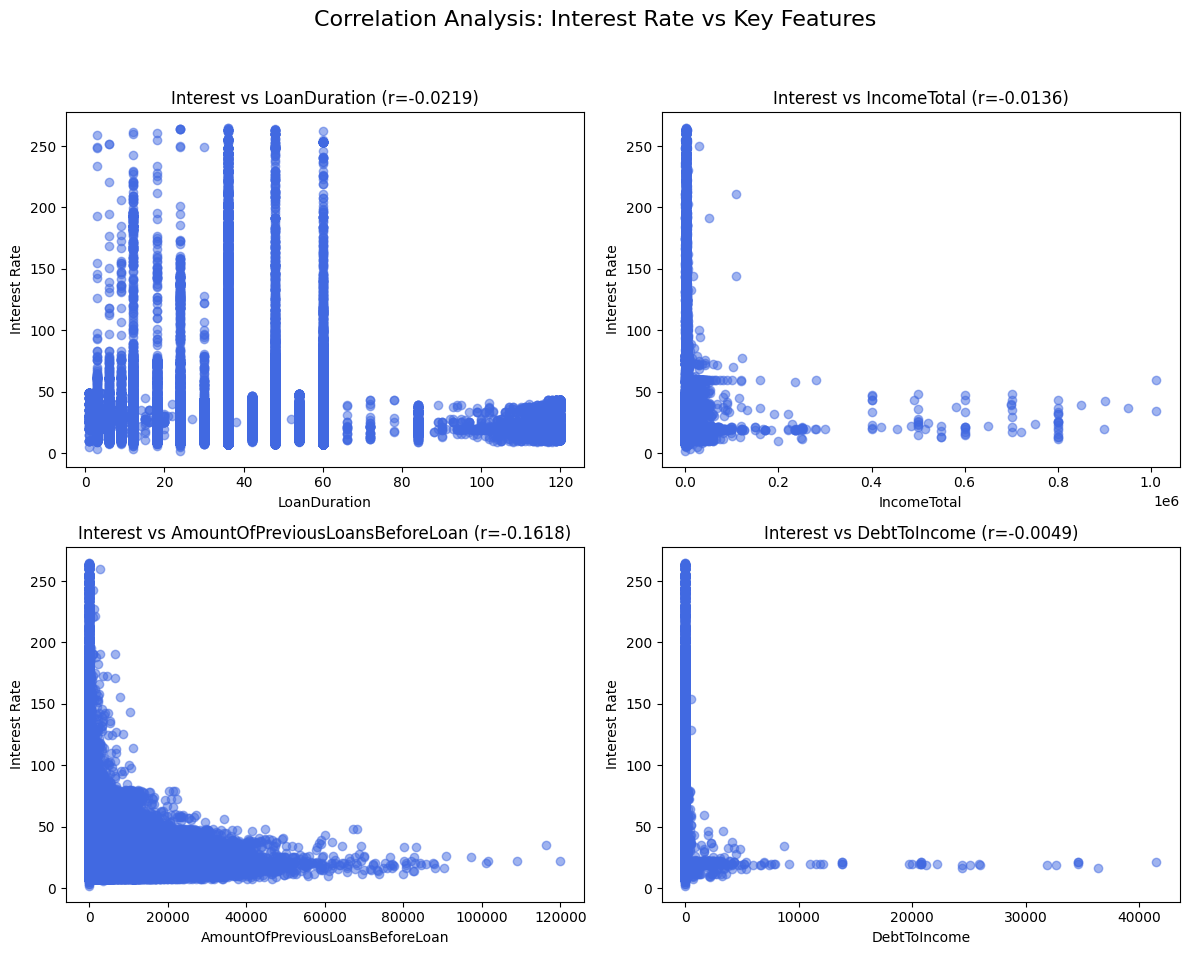

                            OLS Regression Results                            
Dep. Variable:               Interest   R-squared:                       0.617
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                 1.653e+04
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:26:51   Log-Likelihood:            -1.5635e+06
No. Observations:              409951   AIC:                         3.127e+06
Df Residuals:                  409910   BIC:                         3.128e+06
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from math import sqrt
from scipy import stats
import numpy as np

# 1. Load the dataset
df_raw = pd.read_csv("LoanData.csv")

# 2. Define relevant columns for credit risk analysis
selected_columns = [
    "LoanId", "NewCreditCustomer", "LoanDate", "VerificationType", "Age",
    "Gender", "Country", "AppliedAmount", "Amount", "Interest",
    "LoanDuration", "Education", "EmploymentDurationCurrentEmployer",
    "HomeOwnershipType", "IncomeTotal", "ExistingLiabilities",
    "LiabilitiesTotal", "RefinanceLiabilities", "Rating",
    "NoOfPreviousLoansBeforeLoan", "AmountOfPreviousLoansBeforeLoan",
    "PreviousEarlyRepaymentsCountBeforeLoan"
]

# Create a copy for cleaning
df_cleaned = df_raw[selected_columns].copy()

# 3. Handle missing values and data types
# Convert categorical columns to string to prevent type errors
categorical_cols = [
    'EmploymentDurationCurrentEmployer', 'HomeOwnershipType', 
    'Education', 'VerificationType', 'Gender', 'Rating'
]

for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].astype(str)

# Fill categorical missing values
df_cleaned['EmploymentDurationCurrentEmployer'] = df_cleaned['EmploymentDurationCurrentEmployer'].replace('nan', 'Unknown')
df_cleaned['HomeOwnershipType'] = df_cleaned['HomeOwnershipType'].replace('nan', 'Other')
df_cleaned['Education'] = df_cleaned['Education'].replace('nan', df_cleaned['Education'].mode()[0])
df_cleaned['VerificationType'] = df_cleaned['VerificationType'].replace('nan', 'Unknown')
df_cleaned['Gender'] = df_cleaned['Gender'].replace('nan', df_cleaned['Gender'].mode()[0])
df_cleaned['Rating'] = df_cleaned['Rating'].replace('nan', df_cleaned['Rating'].mode()[0])

# Fill numerical missing values
num_cols_to_fill_zero = [
    'PreviousEarlyRepaymentsCountBeforeLoan',
    'AmountOfPreviousLoansBeforeLoan',
    'NoOfPreviousLoansBeforeLoan'
]
for col in num_cols_to_fill_zero:
    df_cleaned[col] = df_cleaned[col].fillna(0)

# 4. Basic Descriptive Statistics
interest_mean = df_cleaned['Interest'].mean()
interest_std = df_cleaned['Interest'].std()
num_less_amount = (df_cleaned['Amount'] < df_cleaned['AppliedAmount']).sum()
rating_proportion = df_cleaned['Rating'].value_counts() / len(df_cleaned)

print(f"Interest Mean: {interest_mean:.2f}")
print(f"Interest Std Dev: {interest_std:.2f}")
print(f"Borrowers with partial funding: {num_less_amount}")
print("\nRating Proportions:\n", rating_proportion.sort_index())

# 5. Strategic Feature Engineering
# Calculate Debt-to-Income ratio
df_cleaned["DebtToIncome"] = df_cleaned["Amount"] / df_cleaned["IncomeTotal"]
df_cleaned["DebtToIncome"] = df_cleaned["DebtToIncome"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Identify high-risk loans based on financial and employment stability
df_cleaned["IsRisky"] = (df_cleaned["DebtToIncome"] >= 0.35) & \
                        df_cleaned["EmploymentDurationCurrentEmployer"].isin(["TrialPeriod", "UpTo1Year"])

# 6. Statistical Inference (Confidence Interval)
n = len(df_cleaned)
phat = num_less_amount / n
se = sqrt(phat * (1 - phat) / n)
confidence_interval = stats.norm.interval(0.95, loc=phat, scale=se)
print(f"\n95% Confidence Interval for partial funding proportion: {confidence_interval}")

# 7. Correlation Analysis Visualization
corr_columns = ["LoanDuration", "IncomeTotal", "AmountOfPreviousLoansBeforeLoan", "DebtToIncome"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Correlation Analysis: Interest Rate vs Key Features", fontsize=16)

for i, col in enumerate(corr_columns):
    ax = axes[i//2, i%2]
    ax.scatter(df_cleaned[col], df_cleaned["Interest"], alpha=0.5, color='royalblue')
    corr_val = df_cleaned[col].corr(df_cleaned["Interest"])
    ax.set_title(f"Interest vs {col} (r={corr_val:.4f})")
    ax.set_xlabel(col)
    ax.set_ylabel("Interest Rate")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Multiple Linear Regression Model (OLS)
# Select predictors and create dummy variables for categorical data
predictors = [
    "AppliedAmount", "Amount", "IncomeTotal", "ExistingLiabilities", 
    "RefinanceLiabilities", "Age", "NoOfPreviousLoansBeforeLoan", 
    "AmountOfPreviousLoansBeforeLoan", "Education", 
    "EmploymentDurationCurrentEmployer", "HomeOwnershipType", "Rating"
]

categorical_to_dummy = [
    "Education", "EmploymentDurationCurrentEmployer", 
    "HomeOwnershipType", "Rating"
]

# Generate design matrix with constant term
X = sm.add_constant(pd.get_dummies(df_cleaned[predictors], columns=categorical_to_dummy, drop_first=True, dtype=float))
Y = df_cleaned["Interest"]

# Fit and summarize the model
model = sm.OLS(Y, X)
results = model.fit()
print(results.summary())